In [14]:
import torch
import torch.nn as nn


In [15]:
class AudioCNNCoach(nn.Module):
def __init__(self, num_clases=3):
super(AudioCNNCoach, self).__init__()


self.bloque1 = nn.Sequential(

nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
nn.BatchNorm2d(16),
nn.ReLU(),
nn.MaxPool2d(kernel_size=2, stride=2)
)


self.bloque2 = nn.Sequential(
nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
nn.BatchNorm2d(32),
nn.ReLU(),
nn.MaxPool2d(kernel_size=2, stride=2)
)

self.flatten = nn.Flatten()



with torch.no_grad():
tensor_prueba = torch.zeros(1, 1, 201, 201)
x_prueba = self.bloque1(tensor_prueba)
x_prueba = self.bloque2(x_prueba)
x_prueba = self.flatten(x_prueba)
tamanio_aplanado = x_prueba.shape[1]

print(f" Tamaño calculado dinámicamente para la capa Flatten: {tamanio_aplanado}")


self.clasificador = nn.Sequential(
nn.Linear(tamanio_aplanado, 64),
nn.ReLU(),
nn.Dropout(p=0.5),
nn.Linear(64, num_clases)
)

def forward(self, x):

x = self.bloque1(x)
x = self.bloque2(x)
x = self.flatten(x)
x = self.clasificador(x)
return x


In [16]:
model = AudioCNNCoach(num_clases=3)


lote_falso = torch.randn(8, 1, 201, 201)
salida_falsa = model(lote_falso)

print(f" Dimensiones de la salida del lote simulado: {salida_falsa.shape}")
print("   (Debe ser [8, 3] -> 8 audios evaluados para 3 clases distintas)")


 Tamaño calculado dinámicamente para la capa Flatten: 80000
 Dimensiones de la salida del lote simulado: torch.Size([8, 3])
   (Debe ser [8, 3] -> 8 audios evaluados para 3 clases distintas)


Dataset inicializado. Total de audios encontrados: 299
 Audios para Entrenamiento (80%): 239
 Audios para Validación/Test (20%): 60
 Tamaño calculado dinámicamente para la capa Flatten: 80000

 ¡Iniciando entrenamiento en CPU! Por favor, espera...
--------------------------------------------------
Época [01/15] -> Loss Train: 4.5140 | Acc Train: 41.4% || Loss Val: 0.9403 | Acc Val: 51.7%
Época [02/15] -> Loss Train: 1.0515 | Acc Train: 39.7% || Loss Val: 0.9712 | Acc Val: 45.0%
Época [03/15] -> Loss Train: 1.0269 | Acc Train: 43.1% || Loss Val: 0.9282 | Acc Val: 50.0%
Época [04/15] -> Loss Train: 1.1141 | Acc Train: 34.7% || Loss Val: 1.0896 | Acc Val: 33.3%
Época [05/15] -> Loss Train: 1.1003 | Acc Train: 33.9% || Loss Val: 1.0971 | Acc Val: 33.3%
Época [06/15] -> Loss Train: 1.1001 | Acc Train: 33.9% || Loss Val: 1.0893 | Acc Val: 33.3%
Época [07/15] -> Loss Train: 1.0902 | Acc Train: 35.6% || Loss Val: 1.0228 | Acc Val: 50.0%
Época [08/15] -> Loss Train: 1.0544 | Acc Train: 43.1% ||

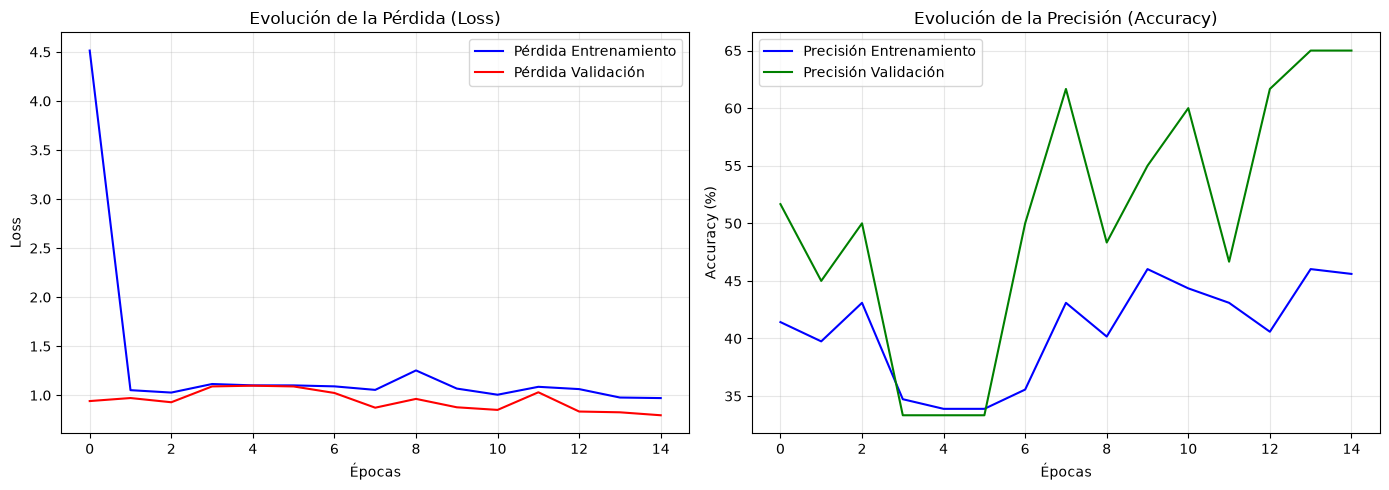

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, random_split, DataLoader
import torchaudio
import matplotlib.pyplot as plt


if 'dataset' not in globals():
class CoachVocalDataset(Dataset):
def __init__(self, directorio_base, duracion_segundos=2, sample_rate=16000):
self.directorio = directorio_base
self.sr_objetivo = sample_rate
self.muestras_objetivo = sample_rate * duracion_segundos
self.clases = {"breathy": 0, "belt": 1, "straight": 2}
self.archivos = []
self.etiquetas = []

for nombre_clase, id_clase in self.clases.items():
ruta_clase = os.path.join(directorio_base, nombre_clase)
if os.path.exists(ruta_clase):
for archivo in os.listdir(ruta_clase):
if archivo.endswith('.wav'):
self.archivos.append(os.path.join(ruta_clase, archivo))
self.etiquetas.append(id_clase)

print(f"Dataset inicializado. Total de audios encontrados: {len(self.archivos)}")

def __len__(self):
return len(self.archivos)

def __getitem__(self, idx):
ruta_audio = self.archivos[idx]
etiqueta = self.etiquetas[idx]

import soundfile as sf
data, sr = sf.read(ruta_audio)

waveform = torch.FloatTensor(data)
if len(waveform.shape) == 1:
waveform = waveform.unsqueeze(0)
else:
waveform = waveform.t()

if waveform.shape[0] > 1:
waveform = torch.mean(waveform, dim=0, keepdim=True)

if sr != self.sr_objetivo:
resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=self.sr_objetivo)
waveform = resampler(waveform)

if waveform.shape[1] > self.muestras_objetivo:
waveform = waveform[:, :self.muestras_objetivo]
elif waveform.shape[1] < self.muestras_objetivo:
pad_amount = self.muestras_objetivo - waveform.shape[1]
waveform = torch.nn.functional.pad(waveform, (0, pad_amount))

transformador = torchaudio.transforms.Spectrogram(n_fft=400, hop_length=160)
espectrograma = transformador(waveform)
espectrograma = torch.log2(espectrograma + 1e-6)

return espectrograma, torch.tensor(etiqueta, dtype=torch.long)

dataset = CoachVocalDataset(directorio_base="datos")





total_audios = len(dataset)
tam_train = int(0.8 * total_audios)
tam_val = total_audios - tam_train


generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(dataset, [tam_train, tam_val], generator=generator)


train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f" Audios para Entrenamiento (80%): {len(train_dataset)}")
print(f" Audios para Validación/Test (20%): {len(val_dataset)}")





model = AudioCNNCoach(num_clases=3)


criterion = nn.CrossEntropyLoss()


optimizer = optim.Adam(model.parameters(), lr=0.001)




EPOCHS = 35
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("\n ¡Iniciando entrenamiento en CPU! Por favor, espera...")
print("-" * 50)

for epoch in range(EPOCHS):

model.train()
running_loss = 0.0
correct_train = 0
total_train = 0

for espectrogramas, etiquetas in train_loader:
outputs = model(espectrogramas)
loss = criterion(outputs, etiquetas)

optimizer.zero_grad()
loss.backward()
optimizer.step()

running_loss += loss.item() * espectrogramas.size(0)

_, predicted = torch.max(outputs, 1)
total_train += etiquetas.size(0)
correct_train += (predicted == etiquetas).sum().item()

epoch_train_loss = running_loss / len(train_dataset)
epoch_train_acc = 100 * correct_train / total_train


model.eval()
running_val_loss = 0.0
correct_val = 0
total_val = 0

with torch.no_grad():
for espectrogramas, etiquetas in val_loader:
outputs = model(espectrogramas)
loss = criterion(outputs, etiquetas)

running_val_loss += loss.item() * espectrogramas.size(0)

_, predicted = torch.max(outputs, 1)
total_val += etiquetas.size(0)
correct_val += (predicted == etiquetas).sum().item()

epoch_val_loss = running_val_loss / len(val_dataset)
epoch_val_acc = 100 * correct_val / total_val

train_losses.append(epoch_train_loss)
val_losses.append(epoch_val_loss)
train_accs.append(epoch_train_acc)
val_accs.append(epoch_val_acc)

print(f"Época [{epoch+1:02d}/{EPOCHS}] -> "
f"Loss Train: {epoch_train_loss:.4f} | Acc Train: {epoch_train_acc:.1f}% || "
f"Loss Val: {epoch_val_loss:.4f} | Acc Val: {epoch_val_acc:.1f}%")




torch.save(model.state_dict(), "modelos/coach_vocal_cnn.pth")
print("\n ¡IA Guardada exitosamente en: modelos/coach_vocal_cnn.pth!")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label="Pérdida Entrenamiento", color="blue")
ax1.plot(val_losses, label="Pérdida Validación", color="red")
ax1.set_title("Evolución de la Pérdida (Loss)")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, label="Precisión Entrenamiento", color="blue")
ax2.plot(val_accs, label="Precisión Validación", color="green")
ax2.set_title("Evolución de la Precisión (Accuracy)")
ax2.set_xlabel("Épocas")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
